In [1]:
# ============================================================
# Contrastive GNN Graph Embedding Training
# Small Connected ER Graphs (Weighted / Unweighted)
# ============================================================

import random
import numpy as np
import torch
from src.utils import read_config


In [2]:
# ------------------------
# IMPORTS
# ------------------------

import os
import networkx as nx
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.decomposition import PCA

from torch_geometric.data import Data, DataLoader
from torch_geometric.utils import from_networkx

import torch.nn as nn
import torch.nn.functional as F

from src.embedding.gnn_model import GNNGraphEncoder

In [9]:
config = read_config(path='config/config.yaml')
SEED = config['gnn']['SEED']

NUM_GRAPHS = config['gnn']['NUM_GRAPHS']
NODE_CHOICES = config['gnn']['NODE_CHOICES']
EDGE_P_MIN = config['gnn']['EDGE_P_MIN']
EDGE_P_MAX = config['gnn']['EDGE_P_MAX']

WEIGHT_UNIFORM_RANGE = config['gnn']['WEIGHT_UNIFORM_RANGE']
WEIGHT_EXP_LAMBDA = config['gnn']['WEIGHT_EXP_LAMBDA']
WEIGHTED_RATIO = config['gnn']['WEIGHTED_RATIO']

NODE_FEATURE_DIM = config['gnn']['NODE_FEATURE_DIM']

EMBEDDING_DIM = config['gnn']['EMBEDDING_DIM']
HIDDEN_DIM = config['gnn']['HIDDEN_DIM']
NUM_LAYERS = config['gnn']['NUM_LAYERS']

EPOCHS = config['gnn']['EPOCHS']
LR = float(config['gnn']['LR'])
WEIGHT_DECAY = float(config['gnn']['WEIGHT_DECAY'])
BATCH_SIZE = config['gnn']['BATCH_SIZE']

TEMPERATURE = config['gnn']['TEMPERATURE']

MODEL_PATH = config['gnn']['MODEL_PATH']


torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [10]:
# ------------------------
# GRAPH GENERATION
# ------------------------

def generate_connected_er_graph(weighted=True):
    n = random.choice(NODE_CHOICES)
    p = random.uniform(EDGE_P_MIN, EDGE_P_MAX)

    while True:
        G = nx.erdos_renyi_graph(n, p)
        if nx.is_connected(G):
            break

    for u, v in G.edges():
        if weighted:
            if random.random() < 0.5:
                w = np.random.uniform(*WEIGHT_UNIFORM_RANGE)
            else:
                w = np.random.exponential(WEIGHT_EXP_LAMBDA)
            G[u][v]["weight"] = float(w)
        else:
            G[u][v]["weight"] = 1.0

    for node in G.nodes():
        G.nodes[node]["x"] = np.random.randn(NODE_FEATURE_DIM)

    return G


graphs = []
graph_types = []

for i in tqdm(range(NUM_GRAPHS), desc="Generating graphs"):
    weighted = random.random() < WEIGHTED_RATIO
    G = generate_connected_er_graph(weighted)
    graphs.append(G)
    graph_types.append(weighted)

print(f"Graphs: {NUM_GRAPHS} | Weighted: {sum(graph_types)}")

Generating graphs: 100%|██████████| 500/500 [00:00<00:00, 7562.51it/s]

Graphs: 500 | Weighted: 389


In [11]:
# ------------------------
# PyG DATASET
# ------------------------

data_list = []

for G in graphs:
    data = from_networkx(G)

    data.x = torch.tensor(
        np.vstack([G.nodes[n]["x"] for n in G.nodes()]),
        dtype=torch.float,
    )

    edge_weights = []
    for u, v in G.edges():
        w = G[u][v]["weight"]
        edge_weights.append(w)
        edge_weights.append(w)  # duplicate for (v, u)

    data.edge_weight = torch.tensor(edge_weights, dtype=torch.float)


    data_list.append(data)

loader = DataLoader(data_list, batch_size=BATCH_SIZE, shuffle=True)

/tmp/ipykernel_1438271/3664740197.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  loader = DataLoader(data_list, batch_size=BATCH_SIZE, shuffle=True)


In [12]:
def augment_graph(data, edge_drop_p=0.1, weight_noise=0.1, x_noise=0.1):
    data = data.clone()

    # Edge dropout
    if edge_drop_p > 0:
        num_edges = data.edge_index.size(1)
        mask = torch.rand(num_edges, device=data.edge_index.device) > edge_drop_p

        data.edge_index = data.edge_index[:, mask]
        if hasattr(data, "edge_weight"):
            data.edge_weight = data.edge_weight[mask]

    # Edge weight noise
    if hasattr(data, "edge_weight"):
        data.edge_weight = data.edge_weight * (
            1.0 + weight_noise * torch.randn_like(data.edge_weight)
        )

    # Node feature noise
    data.x = data.x + x_noise * torch.randn_like(data.x)

    return data


In [13]:
# ------------------------
# CONTRASTIVE LOSS
# ------------------------

def contrastive_loss(z1, z2, temperature=TEMPERATURE):
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)

    logits = torch.mm(z1, z2.t()) / temperature
    labels = torch.arange(z1.size(0), device=z1.device)

    return F.cross_entropy(logits, labels)

In [14]:
# ------------------------
# MODEL + PROJECTION HEAD
# ------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

encoder = GNNGraphEncoder(
    in_dim=NODE_FEATURE_DIM,
    hidden_dim=HIDDEN_DIM,
    embedding_dim=EMBEDDING_DIM,
    num_layers=NUM_LAYERS,
).to(device)

projector = nn.Sequential(
    nn.Linear(EMBEDDING_DIM, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
).to(device)

params = list(encoder.parameters()) + list(projector.parameters())

optimizer = torch.optim.Adam(params, lr=LR, weight_decay=WEIGHT_DECAY)

Device: cuda


In [15]:
# ------------------------
# TRAINING LOOP
# ------------------------

loss_history = []

encoder.train()
projector.train()

for epoch in range(1, EPOCHS + 1):
    total_loss = 0.0

    for batch in loader:
        batch = batch.to(device)

        batch1 = augment_graph(batch)
        batch2 = augment_graph(batch)

        z1 = encoder(batch1.x, batch1.edge_index, batch1.batch)
        z2 = encoder(batch2.x, batch2.edge_index, batch2.batch)

        p1 = projector(z1)
        p2 = projector(z2)

        loss = contrastive_loss(p1, p2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    loss_history.append(avg_loss)

    if epoch % 2 == 0:
        print(f"Epoch {epoch:03d} | Contrastive Loss: {avg_loss:.4f}")

Epoch 002 | Contrastive Loss: 1.1347
Epoch 004 | Contrastive Loss: 0.9158
Epoch 006 | Contrastive Loss: 0.8018
Epoch 008 | Contrastive Loss: 0.7766
Epoch 010 | Contrastive Loss: 0.7496
Epoch 012 | Contrastive Loss: 0.7546
Epoch 014 | Contrastive Loss: 0.7691
Epoch 016 | Contrastive Loss: 0.7430
Epoch 018 | Contrastive Loss: 0.7037
Epoch 020 | Contrastive Loss: 0.7231


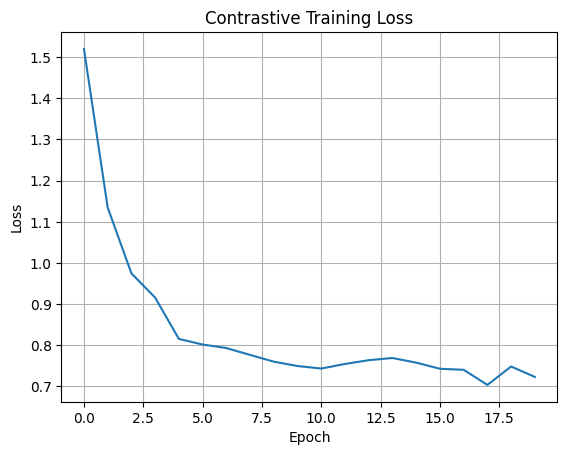

In [16]:
# ------------------------
# LOSS CURVE
# ------------------------

plt.plot(loss_history)
plt.title("Contrastive Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [17]:
# ------------------------
# SAVE ENCODER ONLY
# ------------------------

os.makedirs("models", exist_ok=True)
torch.save(encoder.state_dict(), MODEL_PATH)
print(f"Saved encoder to {MODEL_PATH}")

Saved encoder to models/gnn_graph_encoder_contrastive.pt


In [18]:
# ------------------------
# EXTRACT FINAL GRAPH EMBEDDINGS
# ------------------------

encoder.eval()
embeddings = []

with torch.no_grad():
    for batch in loader:
        batch = batch.to(device)
        emb = encoder(batch.x, batch.edge_index, batch.batch)
        embeddings.append(emb.cpu().numpy())

embeddings = np.vstack(embeddings)
print("Embedding shape:", embeddings.shape)

Embedding shape: (500, 500)


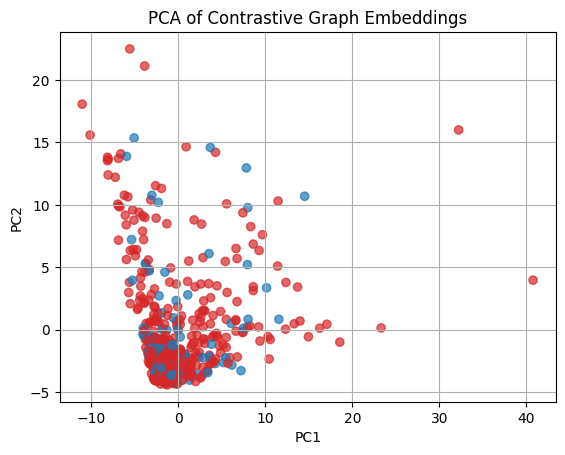

In [19]:
# ------------------------
# PCA VISUALIZATION
# ------------------------

emb_2d = PCA(n_components=2).fit_transform(embeddings)
colors = ["tab:red" if w else "tab:blue" for w in graph_types]

plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=colors, alpha=0.7)
plt.title("PCA of Contrastive Graph Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()